In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ----- Deine Score-Funktionen (angepasst für Logging) -----

def compute_similarity_score(query, proto_pos, proto_neg):
    d_pos = F.pairwise_distance(query.unsqueeze(0), proto_pos.unsqueeze(0))
    d_neg = F.pairwise_distance(query.unsqueeze(0), proto_neg.unsqueeze(0))
    score = (d_neg - d_pos) / (d_neg + d_pos + 1e-8)
    return score.item(), {"d_pos": d_pos.item(), "d_neg": d_neg.item()}

def compute_proto_score(query, supports, labels):
    proto_pos = supports[labels == 1].mean(dim=0)
    proto_neg = supports[labels == 0].mean(dim=0)
    return compute_similarity_score(query, proto_pos, proto_neg)

def compute_soft_knn_score(query, supports, labels, T=1.0):
    sims = F.cosine_similarity(query.unsqueeze(0), supports)
    sims = sims / T
    weights = torch.softmax(sims, dim=0)
    score = torch.sum(weights * (2 * labels - 1))
    return score.item(), {"neighbors": list(zip(labels.tolist(), sims.tolist()))}

def compute_soft_knn_margin(query, supports, labels, T=1.0, top_k=5):
    sims = F.cosine_similarity(query.unsqueeze(0), supports)
    sims = sims / T
    weights = torch.softmax(sims, dim=0)

    weights_pos = torch.sum(weights[labels == 1])
    weights_neg = torch.sum(weights[labels == 0])
    score = weights_pos - weights_neg

    vals, idxs = sims.topk(top_k)
    return score.item(), {
        "topk_neighbors": [(labels[i].item(), vals[j].item()) for j, i in enumerate(idxs)]
    }

# ----- t-SNE Visualisierung -----

def visualize_tsne(query, supports, labels, highlight_idx=None, title=""):
    X = torch.cat([query.unsqueeze(0), supports], dim=0).cpu().numpy()
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)

    q_2d = X_2d[0]
    s_2d = X_2d[1:]

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(s_2d[:,0], s_2d[:,1], c=labels, cmap="tab10", alpha=0.6)
    plt.scatter(q_2d[0], q_2d[1], c="red", marker="*", s=200, label="Query")

    if highlight_idx is not None:
        plt.scatter(s_2d[highlight_idx,0], s_2d[highlight_idx,1],
                    edgecolors="black", facecolors="none", s=150, linewidths=2)

    plt.legend()
    plt.title(title)
    plt.show()

# ----- Master Inspector -----

def inspect_query(query, supports, labels):
    results = {}

    # similarity (mit mean-proto für pos/neg)
    proto_pos = supports[labels == 1].mean(dim=0)
    proto_neg = supports[labels == 0].mean(dim=0)
    score, info = compute_similarity_score(query, proto_pos, proto_neg)
    results["similarity"] = (score, info)

    # proto score
    score, info = compute_proto_score(query, supports, labels)
    results["proto"] = (score, info)

    # soft knn
    score, info = compute_soft_knn_score(query, supports, labels)
    results["soft_knn"] = (score, info)

    # soft knn margin
    score, info = compute_soft_knn_margin(query, supports, labels)
    results["soft_knn_margin"] = (score, info)

    return results



[SIMILARITY] score=-0.017
info: {'d_pos': 8.753711700439453, 'd_neg': 8.460307121276855}

[PROTO] score=-0.017
info: {'d_pos': 8.753711700439453, 'd_neg': 8.460307121276855}

[SOFT_KNN] score=-0.298
info: {'neighbors': [(0, -0.27521297335624695), (1, 0.048123836517333984), (1, -0.1578930765390396), (1, 0.00604565255343914), (0, -0.11517774313688278), (0, 0.056688763201236725), (0, -0.04645533114671707), (0, -0.04252224788069725), (0, 0.11454802751541138), (0, 0.1478952020406723), (0, 0.05048719793558121), (0, -0.05958164483308792), (0, 0.08916790783405304), (0, 0.07482681423425674), (1, -0.0371459499001503), (1, -0.044840872287750244), (0, -0.01363111287355423), (0, 0.04964685067534447), (0, 0.22464779019355774), (0, 0.0476507768034935), (0, 0.134013369679451), (1, -0.11520999670028687), (1, -0.13673581182956696), (1, 0.04742102324962616), (1, -0.017947014421224594), (1, -0.09390620142221451), (0, -0.015705861151218414), (0, 0.043421871960163116), (0, 0.06592260301113129), (0, 0.00648

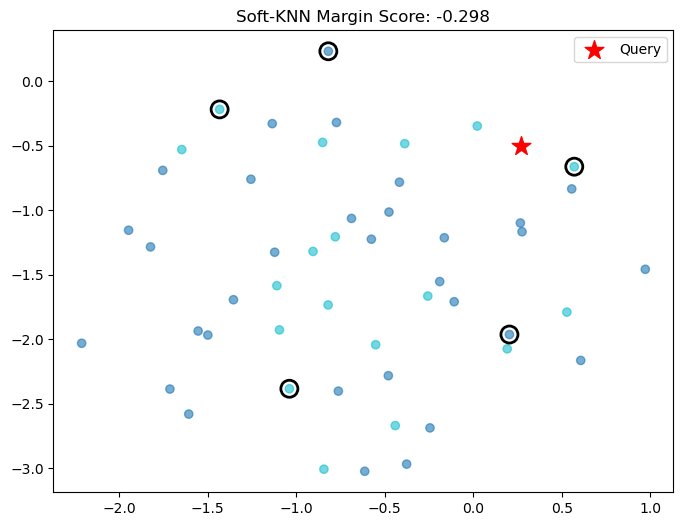

In [4]:
# Fake-Daten zum Testen
supports = torch.randn(50, 64)      # 50 Support Embeddings, 64-dim
labels = torch.randint(0, 2, (50,)) # Binary labels (0/1)
query = torch.randn(64)             # Single query

results = inspect_query(query, supports, labels)

# print Ergebnisse
for method, (score, info) in results.items():
    print(f"\n[{method.upper()}] score={score:.3f}")
    print("info:", info)

# t-SNE für Soft-KNN Margin mit Top-K neighbors highlighten
neighbors_idx = [i for i, _ in enumerate(labels)][:5]  # just as placeholder
visualize_tsne(query, supports, labels, highlight_idx=neighbors_idx,
               title=f"Soft-KNN Margin Score: {results['soft_knn_margin'][0]:.3f}")
